In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import joblib

In [3]:
df = pd.read_csv('diabetes_unclean.csv')
df.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [4]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape: (1009, 14)

Columns: ['ID', 'No_Pation', 'Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS']

Data types:
 ID             int64
No_Pation      int64
Gender           str
AGE          float64
Urea         float64
Cr           float64
HbA1c        float64
Chol         float64
TG           float64
HDL          float64
LDL          float64
VLDL         float64
BMI          float64
CLASS            str
dtype: object

Missing values:
 ID           0
No_Pation    0
Gender       0
AGE          1
Urea         1
Cr           2
HbA1c        3
Chol         2
TG           2
HDL          1
LDL          2
VLDL         1
BMI          0
CLASS        0
dtype: int64


In [5]:
# Drop useless columns
df.drop(columns=['ID', 'No_Pation'], inplace=True)

# Check unique gender values
print("Gender unique values:", df['Gender'].unique())
print("CLASS unique values:", df['CLASS'].unique())

Gender unique values: <StringArray>
['F', 'M', 'f']
Length: 3, dtype: str
CLASS unique values: <StringArray>
['N', 'N ', 'P', 'Y', 'Y ']
Length: 5, dtype: str


In [6]:
# Fix gender typo
df['Gender'] = df['Gender'].str.strip().str.upper()

# Fix CLASS spaces
df['CLASS'] = df['CLASS'].str.strip().str.upper()

# Fill missing values with mean
df['AGE'].fillna(df['AGE'].mean(), inplace=True)
df['Urea'].fillna(df['Urea'].mean(), inplace=True)
df['Cr'].fillna(df['Cr'].mean(), inplace=True)
df['HbA1c'].fillna(df['HbA1c'].mean(), inplace=True)
df['Chol'].fillna(df['Chol'].mean(), inplace=True)
df['TG'].fillna(df['TG'].mean(), inplace=True)
df['HDL'].fillna(df['HDL'].mean(), inplace=True)
df['LDL'].fillna(df['LDL'].mean(), inplace=True)
df['VLDL'].fillna(df['VLDL'].mean(), inplace=True)

# Verify fixes
print("Gender unique:", df['Gender'].unique())
print("CLASS unique:", df['CLASS'].unique())
print("Missing values remaining:\n", df.isnull().sum())

Gender unique: <StringArray>
['F', 'M']
Length: 2, dtype: str
CLASS unique: <StringArray>
['N', 'P', 'Y']
Length: 3, dtype: str
Missing values remaining:
 Gender    0
AGE       1
Urea      1
Cr        2
HbA1c     3
Chol      2
TG        2
HDL       1
LDL       2
VLDL      1
BMI       0
CLASS     0
dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12220\2839392850.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['AGE'].fillna(df['AGE'].mean(), inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12220\2839392850.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignme

In [7]:
# Fix gender typo
df['Gender'] = df['Gender'].str.strip().str.upper()

# Fix CLASS spaces
df['CLASS'] = df['CLASS'].str.strip().str.upper()

# Fill missing values with mean (new pandas style)
cols_with_missing = ['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL']
for col in cols_with_missing:
    df[col] = df[col].fillna(df[col].mean())

# Verify fixes
print("Gender unique:", df['Gender'].unique())
print("CLASS unique:", df['CLASS'].unique())
print("Missing values remaining:\n", df.isnull().sum())

Gender unique: <StringArray>
['F', 'M']
Length: 2, dtype: str
CLASS unique: <StringArray>
['N', 'P', 'Y']
Length: 3, dtype: str
Missing values remaining:
 Gender    0
AGE       0
Urea      0
Cr        0
HbA1c     0
Chol      0
TG        0
HDL       0
LDL       0
VLDL      0
BMI       0
CLASS     0
dtype: int64


In [8]:
# One-hot encode Gender column
df = pd.get_dummies(df, columns=['Gender'])

# Check result
print("Columns now:", df.columns.tolist())
print("Shape now:", df.shape)
df.head()

Columns now: ['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS', 'Gender_F', 'Gender_M']
Shape now: (1009, 13)


,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS,Gender_F,Gender_M
0,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N,True,False
1,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N,False,True
2,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N,True,False
3,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N,True,False
4,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N,False,True


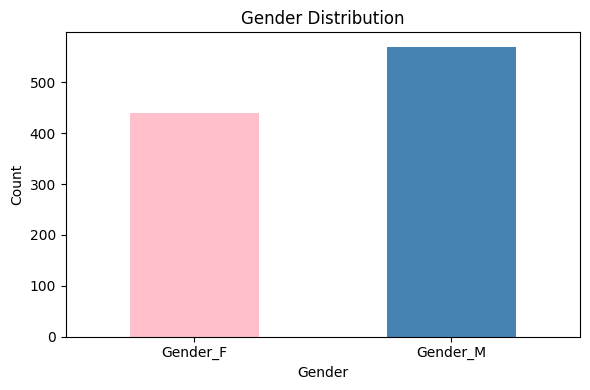

In [9]:
# 1. Bar chart - Gender distribution
plt.figure(figsize=(6,4))
df[['Gender_F', 'Gender_M']].sum().plot(kind='bar', color=['pink', 'steelblue'])
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

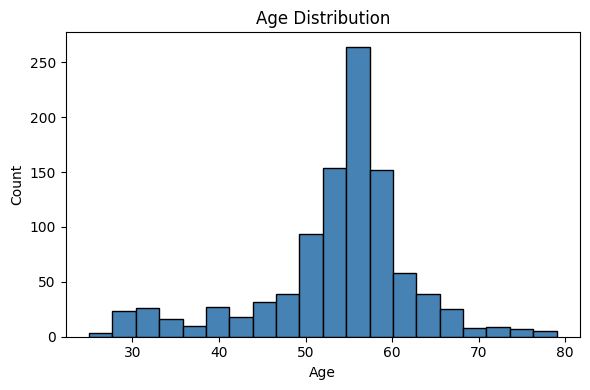

In [10]:
# 2. Histogram - Age distribution
plt.figure(figsize=(6,4))
plt.hist(df['AGE'], bins=20, color='steelblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

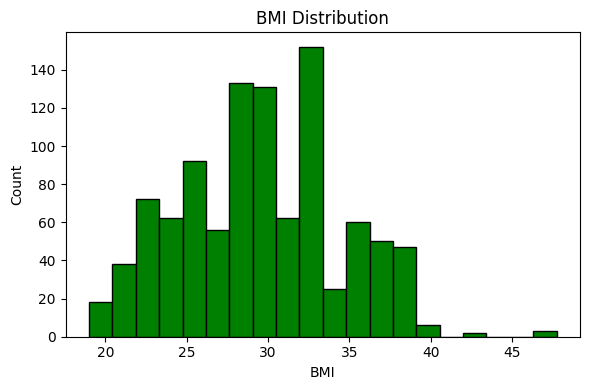

In [11]:
# 3. Histogram - BMI distribution
plt.figure(figsize=(6,4))
plt.hist(df['BMI'], bins=20, color='green', edgecolor='black')
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

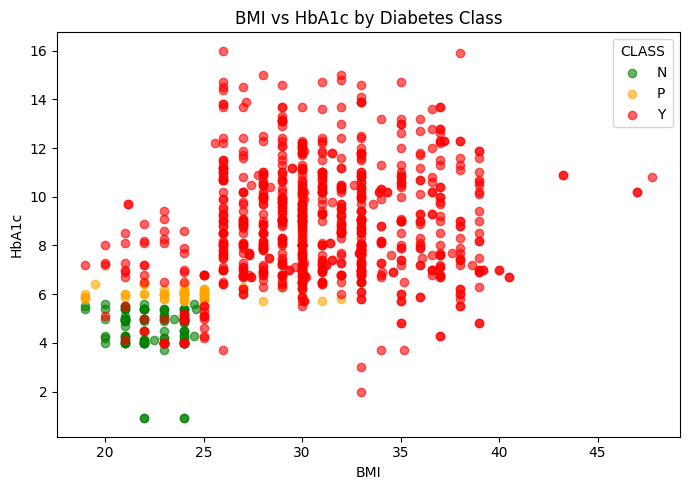

In [12]:
# 4. Scatter plot - BMI vs HbA1c colored by CLASS
plt.figure(figsize=(7,5))
colors = {'N': 'green', 'P': 'orange', 'Y': 'red'}
for cls in df['CLASS'].unique():
    subset = df[df['CLASS'] == cls]
    plt.scatter(subset['BMI'], subset['HbA1c'], 
                label=cls, color=colors[cls], alpha=0.6)
plt.title('BMI vs HbA1c by Diabetes Class')
plt.xlabel('BMI')
plt.ylabel('HbA1c')
plt.legend(title='CLASS')
plt.tight_layout()
plt.show()

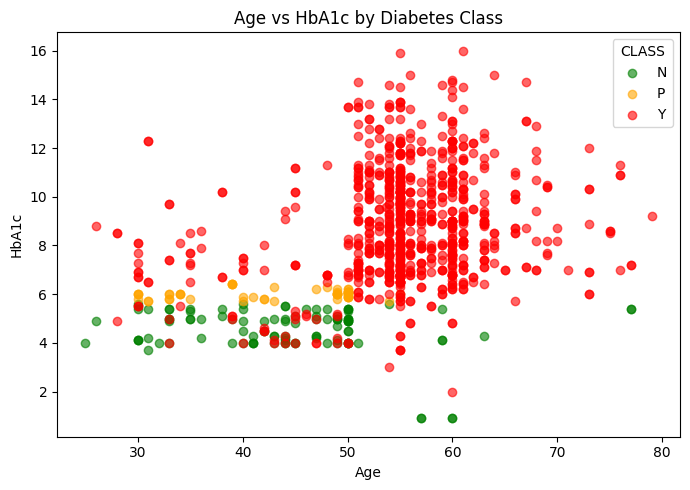

In [13]:
# 5. Scatter plot - Age vs HbA1c colored by CLASS
plt.figure(figsize=(7,5))
colors = {'N': 'green', 'P': 'orange', 'Y': 'red'}
for cls in df['CLASS'].unique():
    subset = df[df['CLASS'] == cls]
    plt.scatter(subset['AGE'], subset['HbA1c'], 
                label=cls, color=colors[cls], alpha=0.6)
plt.title('Age vs HbA1c by Diabetes Class')
plt.xlabel('Age')
plt.ylabel('HbA1c')
plt.legend(title='CLASS')
plt.tight_layout()
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12220\98239571.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='CLASS', y='BMI',


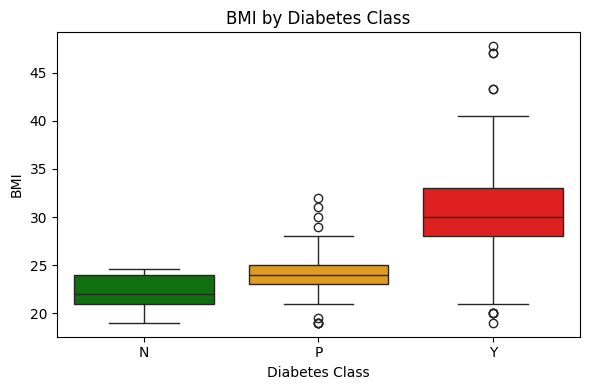

In [14]:
# 6. Box plot - BMI by diabetes class
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='CLASS', y='BMI', 
            palette={'N': 'green', 'P': 'orange', 'Y': 'red'})
plt.title('BMI by Diabetes Class')
plt.xlabel('Diabetes Class')
plt.ylabel('BMI')
plt.tight_layout()
plt.show()

In [15]:
# Split data into features and target
X = df.drop(columns=['CLASS'])
y = df['CLASS']

# 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)


Training size: (706, 12)
Testing size: (303, 12)


In [16]:
# Define all models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'KNN': KNeighborsClassifier()
}

# Train and evaluate each model
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted')
    })

# Show results table
results_df = pd.DataFrame(results)
results_df = results_df.round(4)
display(results_df)

C:\Users\Lenovo\Desktop\Diabetes-Assignment\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Lenovo\Desktop\Diabetes-Assignment\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.9439,0.9393,0.9439,0.9398
1,SVM,0.8482,0.7194,0.8482,0.7785
2,Decision Tree,0.9835,0.9834,0.9835,0.9834
3,Random Forest,0.9769,0.9771,0.9769,0.9759
4,KNN,0.9043,0.9160,0.9043,0.9093


In [17]:
# Save best model
best_model = models['Decision Tree']
joblib.dump(best_model, 'diabetes_model.pkl')

# Save training columns
training_columns = list(X_train.columns)
joblib.dump(training_columns, 'training_columns.pkl')

print("Model saved!")
print("Training columns:", training_columns)

Model saved!
Training columns: ['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI', 'Gender_F', 'Gender_M']
